# 02 — Cost Decomposition & EaaS Mechanism

**Purpose:** Produces the headline thesis figures showing how EaaS transforms system cost composition and investment trajectories.  
**Prerequisite scripts:** `01_run_baseline.py`, `02_run_ndc_caps.py`, `03_run_ndc_eaas.py`  
**Data loaded from:** `results/baseline/`, `results/ndc/`, `results/ndc_eaas/`  

---

This notebook produces six analysis sections:

1. **Cost decomposition** — Real expenditure vs VoLL penalty across all headline cases
2. **EaaS financing gap** — Where public budget exhausts and private capital fills
3. **Solar deployment comparison** — Public-only vs EaaS investment trajectories
4. **Storage deployment** — How EaaS unlocks budget for storage
5. **Generation mix evolution** — How EaaS changes the gas-solar balance over time
6. **Unserved energy and EaaS savings summary**

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path(".").resolve().parent
sys.path.append(str(ROOT))

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 200,
})

FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CANONICAL_VOLL = "voll_mid"

print(f"Repo root: {ROOT}")

Repo root: C:\Users\pc\Desktop\MSc\AUST\Thesis\thesis-repo\thesis-code


## Helper: Load diagnostics and timeseries for a case

In [2]:
def load_case(results_subdir, case_name, voll=CANONICAL_VOLL):
    """
    Load diagnostics.json, summary.json, and timeseries.csv for a case.
    
    Parameters
    ----------
    results_subdir : str
        e.g. 'baseline', 'ndc', 'ndc_eaas', 'eaas'
    case_name : str
        e.g. 'ndc3_unconditional', or empty string for baseline/eaas
    """
    if results_subdir in ("baseline", "eaas"):
        case_dir = ROOT / "results" / results_subdir
    else:
        case_dir = ROOT / "results" / results_subdir / f"{case_name}_{voll}"
    
    out = {"dir": case_dir}
    
    diag_path = case_dir / "diagnostics.json"
    if diag_path.exists():
        with open(diag_path) as f:
            out["diag"] = json.load(f)
    else:
        print(f"WARNING: {diag_path} not found")
        out["diag"] = None
    
    summary_path = case_dir / "summary.json"
    if summary_path.exists():
        with open(summary_path) as f:
            out["summary"] = json.load(f)
    else:
        out["summary"] = None
    
    ts_path = case_dir / "timeseries.csv"
    if ts_path.exists():
        out["ts"] = pd.read_csv(ts_path)
    else:
        out["ts"] = None
    
    return out


# ── Load all headline cases ────────────────────────────────
cases = {
    "Baseline":           load_case("baseline", ""),
    "NDC3 uncond public": load_case("ndc", "ndc3_unconditional"),
    "NDC3 uncond EaaS":   load_case("ndc_eaas", "ndc3_unconditional_eaas"),
    "NDC3 cond public":   load_case("ndc", "ndc3_conditional"),
    "NDC3 cond EaaS":     load_case("ndc_eaas", "ndc3_conditional_eaas"),
}

# Verify all loaded
for name, data in cases.items():
    status = []
    if data["diag"] is not None: status.append("diag")
    if data["summary"] is not None: status.append("summary")
    if data["ts"] is not None: status.append("ts")
    print(f"  {name:25s} -> {', '.join(status) if status else 'MISSING'}")

  Baseline                  -> diag, summary, ts
  NDC3 uncond public        -> diag, summary, ts
  NDC3 uncond EaaS          -> diag, summary, ts
  NDC3 cond public          -> diag, summary, ts
  NDC3 cond EaaS            -> diag, summary, ts


## 1. Cost Decomposition: Real Expenditure vs VoLL Penalty

The central thesis figure. Shows that EaaS cost savings come from avoiding  
blackout penalties, not from reducing real capital expenditure.

In [3]:
# ── Extract cost decomposition ─────────────────────────────
decomp_rows = []
for label, data in cases.items():
    if data["diag"] is None:
        continue
    decomp = data["diag"].get("cost_decomposition", None)
    if decomp is None:
        print(f"WARNING: {label} has no cost_decomposition")
        continue
    decomp_rows.append({
        "Case": label,
        "Real expenditure ($B)": decomp["real_expenditure_npv"] / 1e9,
        "VoLL penalty ($B)": decomp["voll_penalty_npv"] / 1e9,
        "Total ($B)": (decomp["real_expenditure_npv"] + decomp["voll_penalty_npv"]) / 1e9,
        "VoLL share": decomp["voll_penalty_share"],
        "Gas opex ($B)": decomp["components"]["gas_opex_npv"] / 1e9,
        "Gas capex ($B)": decomp["components"]["gas_capex_npv"] / 1e9,
        "Public solar ($B)": decomp["components"]["public_solar_capex_npv"] / 1e9,
        "EaaS solar ($B)": decomp["components"]["eaas_solar_capex_npv"] / 1e9,
        "Storage ($B)": decomp["components"]["storage_capex_npv"] / 1e9,
        "Carbon ($B)": decomp["components"]["carbon_cost_npv"] / 1e9,
    })

decomp_df = pd.DataFrame(decomp_rows)
display(decomp_df[["Case", "Real expenditure ($B)", "VoLL penalty ($B)",
                    "Total ($B)", "VoLL share"]].style.hide(
    axis="index").set_caption(
    "Table 1: System Cost Decomposition").format({
    "Real expenditure ($B)": "${:.1f}B",
    "VoLL penalty ($B)": "${:.1f}B",
    "Total ($B)": "${:.1f}B",
    "VoLL share": "{:.1%}",
}))

Case,Real expenditure ($B),VoLL penalty ($B),Total ($B),VoLL share
Baseline,$9.3B,$0.0B,$9.3B,0.0%
NDC3 uncond public,$7.0B,$469.6B,$476.5B,98.5%
NDC3 uncond EaaS,$11.4B,$15.3B,$26.7B,57.4%
NDC3 cond public,$9.9B,$118.2B,$128.1B,92.3%
NDC3 cond EaaS,$11.8B,$17.8B,$29.7B,60.1%


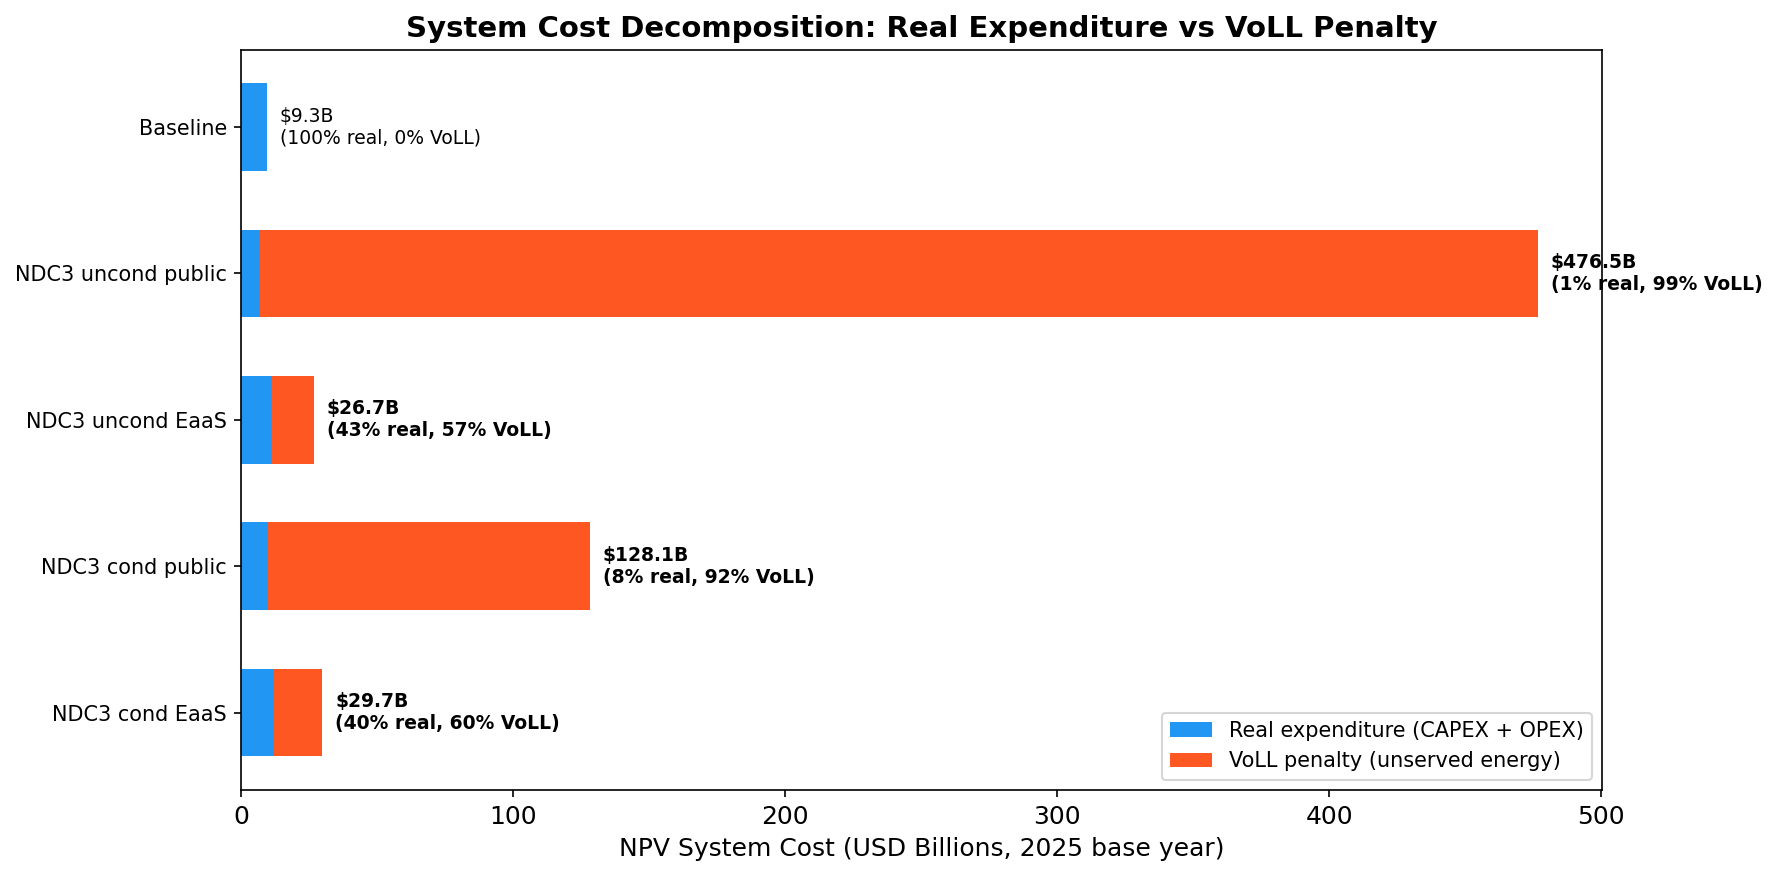

Saved: cost_decomposition.png


In [4]:
# ── Stacked horizontal bar chart ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

labels = decomp_df["Case"].values
real_vals = decomp_df["Real expenditure ($B)"].values
voll_vals = decomp_df["VoLL penalty ($B)"].values
total_vals = decomp_df["Total ($B)"].values

y_pos = np.arange(len(labels))

ax.barh(y_pos, real_vals, height=0.6,
        color="#2196F3", label="Real expenditure (CAPEX + OPEX)")
ax.barh(y_pos, voll_vals, height=0.6, left=real_vals,
        color="#FF5722", label="VoLL penalty (unserved energy)")

for i in range(len(labels)):
    total = total_vals[i]
    real_pct = real_vals[i] / total * 100 if total > 0 else 0
    voll_pct = voll_vals[i] / total * 100 if total > 0 else 0
    ax.text(total + max(total_vals) * 0.01, y_pos[i],
            f"${total:.1f}B\n({real_pct:.0f}% real, {voll_pct:.0f}% VoLL)",
            va="center", ha="left", fontsize=9,
            fontweight="bold" if voll_pct > 50 else "normal")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("NPV System Cost (USD Billions, 2025 base year)")
ax.set_title("System Cost Decomposition: Real Expenditure vs VoLL Penalty",
             fontweight="bold")
ax.legend(loc="lower right")
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "cost_decomposition.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "cost_decomposition.pdf", bbox_inches="tight")
plt.show()
print("Saved: cost_decomposition.png")

In [5]:
# ── Detailed component breakdown table ─────────────────────
comp_cols = ["Case", "Gas opex ($B)", "Gas capex ($B)", "Public solar ($B)",
             "EaaS solar ($B)", "Storage ($B)", "Carbon ($B)", "VoLL penalty ($B)"]
display(decomp_df[comp_cols].style.hide(axis="index").set_caption(
    "Table 2: Detailed Cost Component Breakdown").format(
    {c: "${:.2f}B" for c in comp_cols if c != "Case"}))

Case,Gas opex ($B),Gas capex ($B),Public solar ($B),EaaS solar ($B),Storage ($B),Carbon ($B),VoLL penalty ($B)
Baseline,$2.91B,$0.00B,$6.40B,$0.00B,$0.00B,$0.00B,$0.00B
NDC3 uncond public,$2.41B,$0.00B,$4.55B,$0.00B,$0.00B,$0.00B,$469.58B
NDC3 uncond EaaS,$2.41B,$0.00B,$3.42B,$3.88B,$1.64B,$0.00B,$15.30B
NDC3 cond public,$2.18B,$0.00B,$7.74B,$0.00B,$0.00B,$0.00B,$118.22B
NDC3 cond EaaS,$2.18B,$0.00B,$3.79B,$4.21B,$1.64B,$0.00B,$17.83B


**Interpretation:**

Real expenditure is stable at \$7–12B across all scenarios. The cost variation is driven  
entirely by VoLL penalties. EaaS does not reduce real capital spending — it eliminates  
the social cost of blackouts caused by capital-constrained solar deployment.

Under public-only tight capital, the component breakdown shows public solar CAPEX  
consuming the entire budget with zero remaining for storage. EaaS shifts solar to  
private capital, freeing public budget for storage deployment.

## 2. EaaS Financing Gap Analysis

Quantifies the gap between what public capital can fund and what NDC compliance requires.

In [7]:
from src.scenarios import capital_envelope_scenarios

cap_env = capital_envelope_scenarios()

gap_rows = []
for label, data in cases.items():
    if label == "Baseline" or data["summary"] is None or data["diag"] is None:
        continue
    
    summary = data["summary"]
    diag = data["diag"]
    
    capital_case = summary.get("capital_case", "unknown")
    budget = cap_env.get(capital_case, None)
    budget_b = budget / 1e9 if budget is not None else float("inf")
    
    pub_solar_spend = (diag.get("ndc_finance_public_solar_npv_usd") or 0) / 1e9
    eaas_private = (diag.get("eaas_private_investment_usd") or 0) / 1e9
    utilisation = (diag.get("public_budget_utilisation") or 0)
    realised_spend = (diag.get("public_budget_realised_spend_usd") or 0) / 1e9
    
    gap_rows.append({
        "Case": label,
        "Capital case": capital_case,
        "Budget ($B)": budget_b,
        "Realised spend ($B)": realised_spend,
        "EaaS private ($B)": eaas_private,
        "Budget utilisation": utilisation,
        "Unserved (TWh)": summary["cumulative_unserved_twh"],
    })

gap_df = pd.DataFrame(gap_rows)
display(gap_df.style.hide(axis="index").set_caption(
    "Table 3: EaaS Financing Gap Analysis").format({
    "Budget ($B)": "${:.2f}B",
    "Realised spend ($B)": "${:.2f}B",
    "EaaS private ($B)": "${:.2f}B",
    "Budget utilisation": "{:.1%}",
    "Unserved (TWh)": "{:.1f}",
}))

Case,Capital case,Budget ($B),Realised spend ($B),EaaS private ($B),Budget utilisation,Unserved (TWh)
NDC3 uncond public,tight,$4.55B,$0.00B,$0.00B,0.0%,88.3
NDC3 uncond EaaS,tight,$4.55B,$0.00B,$3.88B,0.0%,1.5
NDC3 cond public,moderate,$7.74B,$0.00B,$0.00B,0.0%,21.7
NDC3 cond EaaS,moderate,$7.74B,$0.00B,$4.21B,0.0%,1.8


## 3. Solar Deployment Trajectories

Compares year-by-year solar capacity under public-only vs EaaS financing.

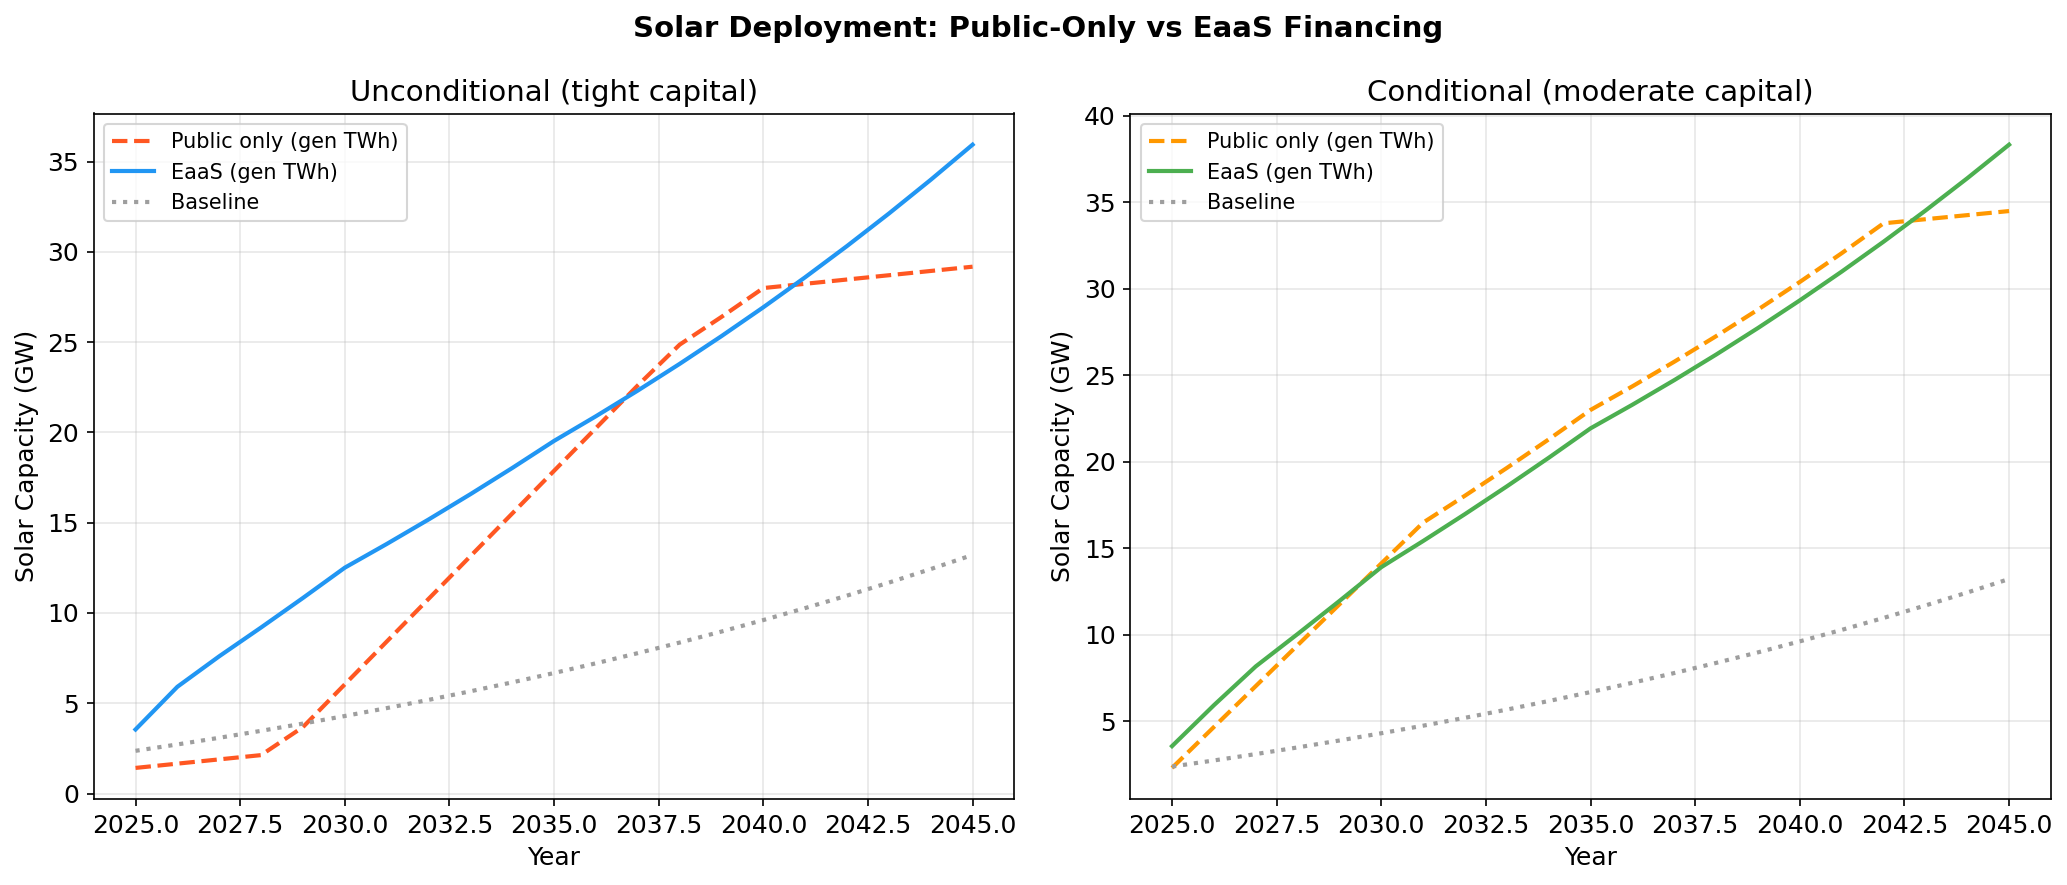

Saved: solar_deployment_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_cases = {
    "Unconditional (tight capital)": [
        ("NDC3 uncond public", "Public only", "#FF5722", "--"),
        ("NDC3 uncond EaaS", "EaaS", "#2196F3", "-"),
        ("Baseline", "Baseline", "#9E9E9E", ":"),
    ],
    "Conditional (moderate capital)": [
        ("NDC3 cond public", "Public only", "#FF9800", "--"),
        ("NDC3 cond EaaS", "EaaS", "#4CAF50", "-"),
        ("Baseline", "Baseline", "#9E9E9E", ":"),
    ],
}

for idx, (panel_title, case_list) in enumerate(plot_cases.items()):
    ax = axes[idx]
    for case_key, line_label, color, ls in case_list:
        ts = cases[case_key]["ts"]
        if ts is not None and "solar_capacity_mw" in ts.columns:
            ax.plot(ts["year"], ts["solar_capacity_mw"] / 1e3,
                    label=line_label, color=color, linestyle=ls, linewidth=2)
        elif ts is not None:
            ax.plot(ts["year"], ts["solar_generation_twh_e"],
                    label=f"{line_label} (gen TWh)", color=color,
                    linestyle=ls, linewidth=2)
    ax.set_xlabel("Year")
    ax.set_ylabel("Solar Capacity (GW)")
    ax.set_title(panel_title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Solar Deployment: Public-Only vs EaaS Financing",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "solar_deployment_comparison.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "solar_deployment_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved: solar_deployment_comparison.png")

## 4. Storage Deployment Comparison

Shows how EaaS enables storage by freeing public budget.

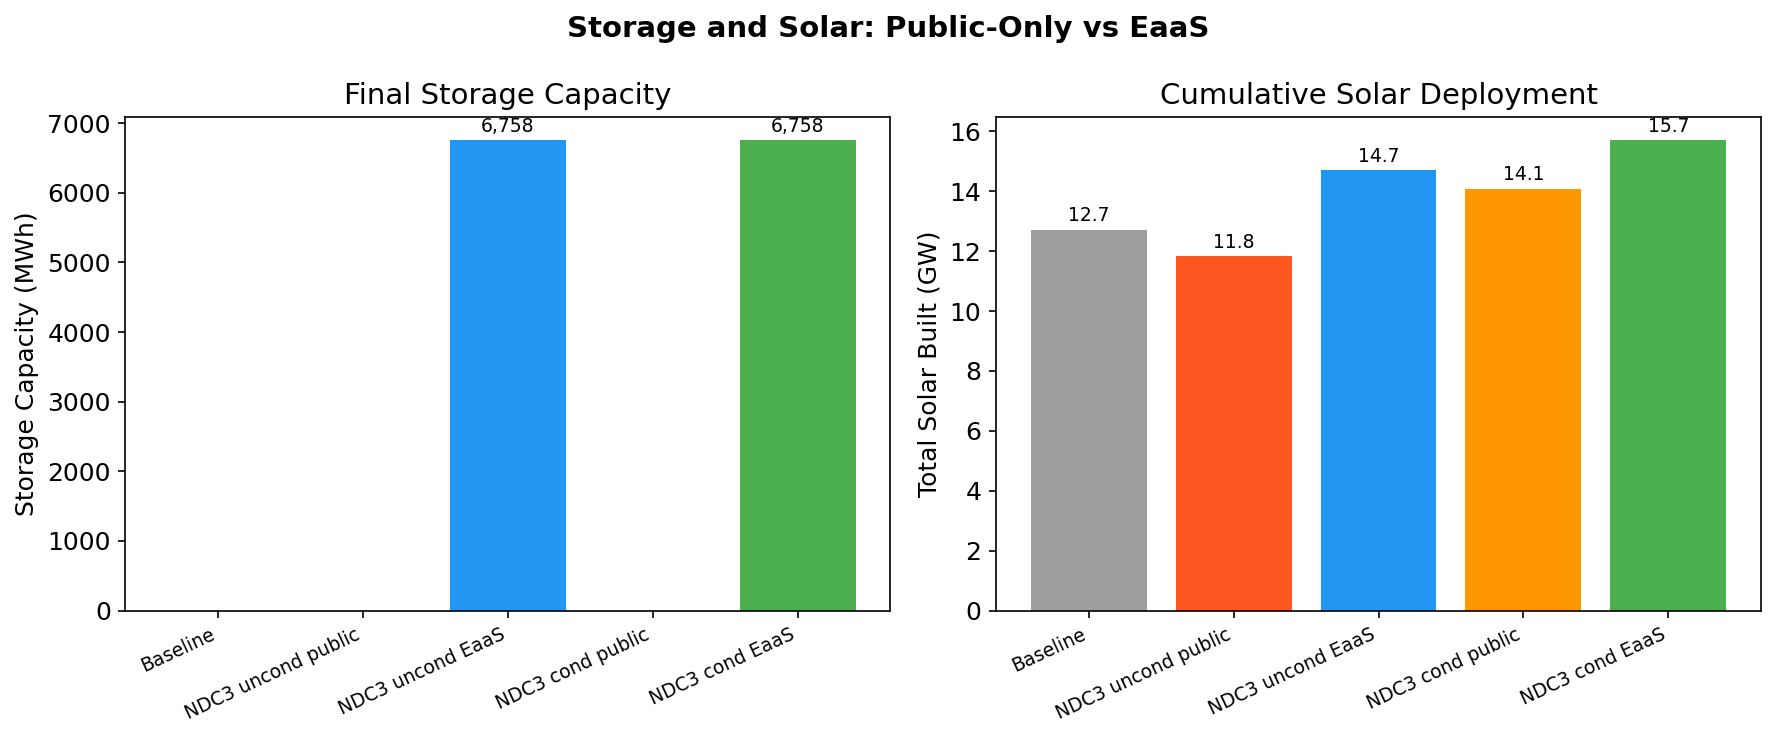

Saved: storage_solar_comparison.png


In [9]:
storage_rows = []
for label, data in cases.items():
    if data["summary"] is None:
        continue
    dv = data["summary"]["decision_variables"]
    storage_mwh = dv.get("final_storage_capacity_mwh",
                         dv.get("storage_capacity_mwh", 0))
    solar_mw = dv.get("solar_total_built_mw", 0)
    storage_rows.append({
        "Case": label,
        "Storage (MWh)": storage_mwh,
        "Solar (MW)": solar_mw,
    })

storage_df = pd.DataFrame(storage_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#9E9E9E", "#FF5722", "#2196F3", "#FF9800", "#4CAF50"]

# Panel 1: Storage
ax = axes[0]
bars = ax.bar(range(len(storage_df)), storage_df["Storage (MWh)"].values,
              color=colors[:len(storage_df)])
ax.set_xticks(range(len(storage_df)))
ax.set_xticklabels(storage_df["Case"].values, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Storage Capacity (MWh)")
ax.set_title("Final Storage Capacity")
for bar in bars:
    if bar.get_height() > 0:
        ax.annotate(f"{bar.get_height():,.0f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)

# Panel 2: Solar
ax = axes[1]
bars = ax.bar(range(len(storage_df)), storage_df["Solar (MW)"].values / 1e3,
              color=colors[:len(storage_df)])
ax.set_xticks(range(len(storage_df)))
ax.set_xticklabels(storage_df["Case"].values, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Total Solar Built (GW)")
ax.set_title("Cumulative Solar Deployment")
for bar in bars:
    ax.annotate(f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9)

plt.suptitle("Storage and Solar: Public-Only vs EaaS",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "storage_solar_comparison.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "storage_solar_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved: storage_solar_comparison.png")

## 5. Generation Mix Evolution

How the gas-solar-storage balance shifts over the planning horizon.

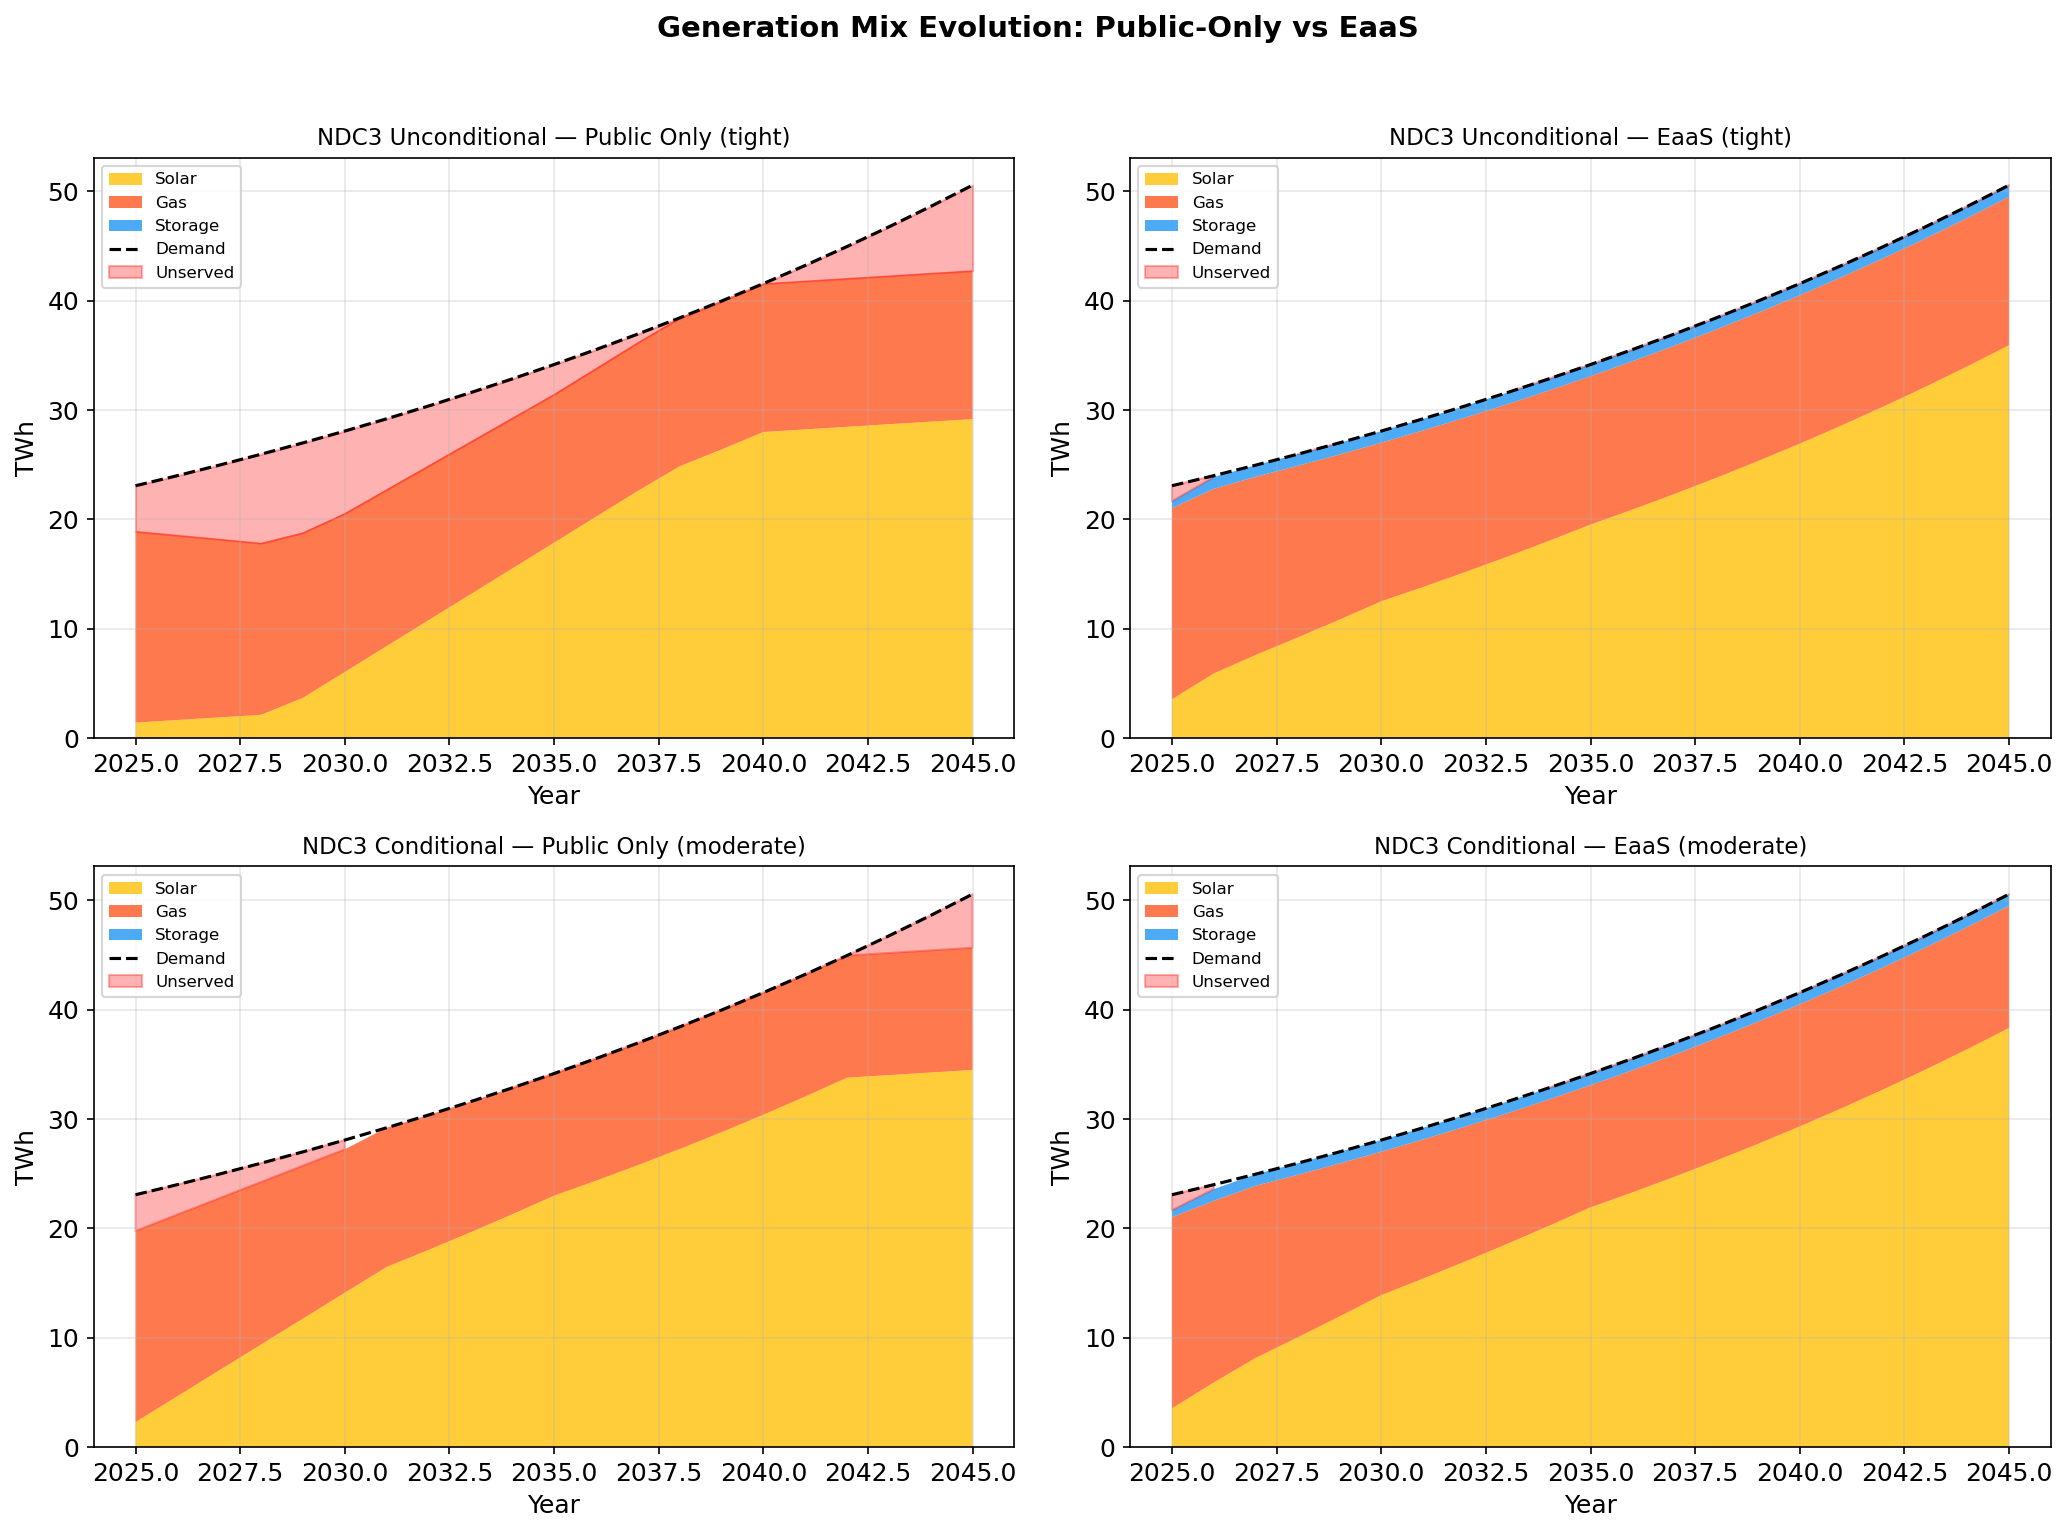

Saved: generation_mix_comparison.png


In [10]:
mix_cases = [
    ("NDC3 uncond public", "NDC3 Unconditional — Public Only (tight)"),
    ("NDC3 uncond EaaS", "NDC3 Unconditional — EaaS (tight)"),
    ("NDC3 cond public", "NDC3 Conditional — Public Only (moderate)"),
    ("NDC3 cond EaaS", "NDC3 Conditional — EaaS (moderate)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (case_key, title) in enumerate(mix_cases):
    ax = axes[idx // 2, idx % 2]
    ts = cases[case_key]["ts"]
    if ts is None:
        ax.text(0.5, 0.5, "Data not available", transform=ax.transAxes, ha="center")
        ax.set_title(title)
        continue
    
    ax.stackplot(ts["year"],
                 ts["solar_generation_twh_e"],
                 ts["gas_generation_twh_e"],
                 ts["storage_discharge_twh_e"],
                 labels=["Solar", "Gas", "Storage"],
                 colors=["#FFC107", "#FF5722", "#2196F3"],
                 alpha=0.8)
    ax.plot(ts["year"], ts["demand_twh"], "k--", linewidth=1.5, label="Demand")
    
    total_gen = (ts["solar_generation_twh_e"] + ts["gas_generation_twh_e"]
                 + ts["storage_discharge_twh_e"])
    ax.fill_between(ts["year"], total_gen, ts["demand_twh"],
                    where=ts["demand_twh"] > total_gen,
                    color="red", alpha=0.3, label="Unserved")
    
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Generation Mix Evolution: Public-Only vs EaaS",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "generation_mix_comparison.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "generation_mix_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved: generation_mix_comparison.png")

## 6. Unserved Energy and EaaS Savings Summary

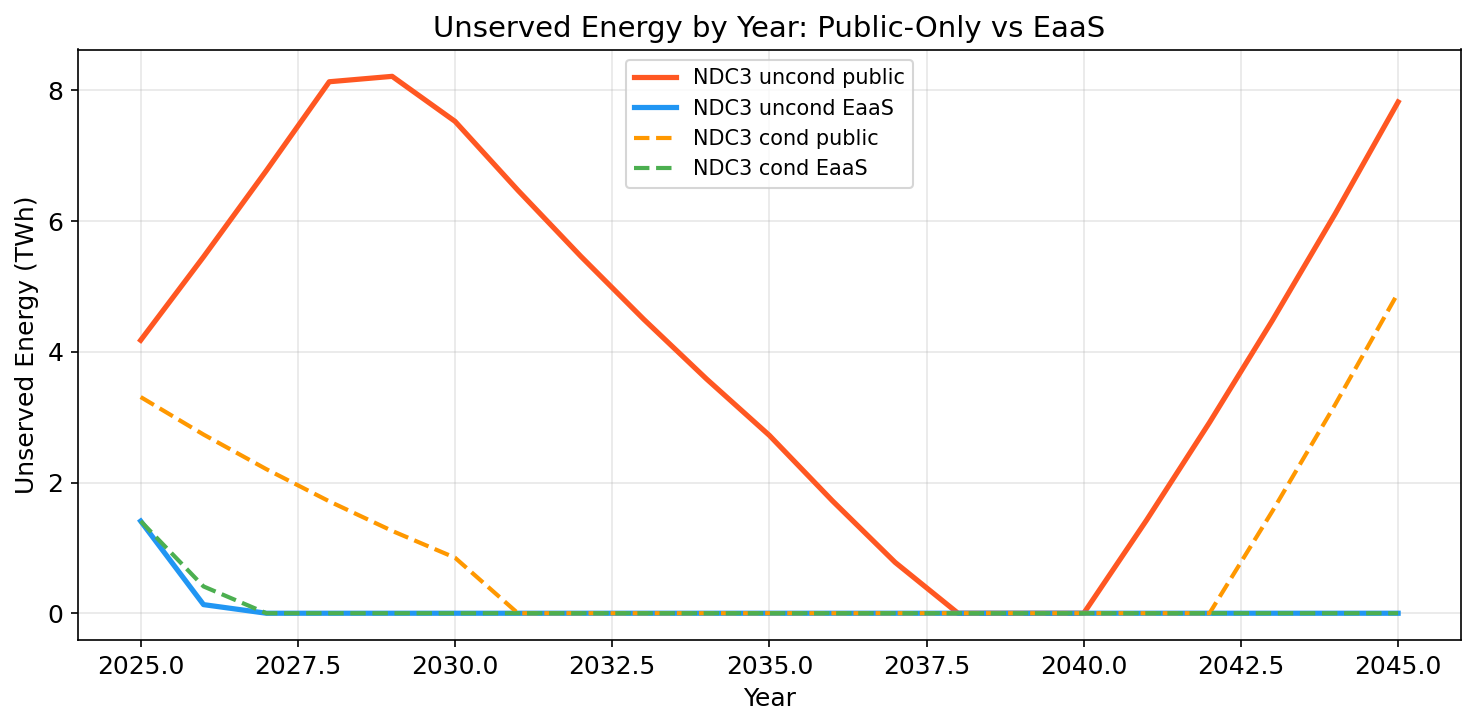

Saved: unserved_energy_comparison.png


In [11]:
# ── Unserved energy by year ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

line_styles = {
    "NDC3 uncond public": ("#FF5722", "-", 2.5),
    "NDC3 uncond EaaS":   ("#2196F3", "-", 2.5),
    "NDC3 cond public":   ("#FF9800", "--", 2),
    "NDC3 cond EaaS":     ("#4CAF50", "--", 2),
}

for case_key, (color, ls, lw) in line_styles.items():
    ts = cases[case_key]["ts"]
    if ts is not None:
        ax.plot(ts["year"], ts["unserved_twh"],
                label=case_key, color=color, linestyle=ls, linewidth=lw)

ax.set_xlabel("Year")
ax.set_ylabel("Unserved Energy (TWh)")
ax.set_title("Unserved Energy by Year: Public-Only vs EaaS")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "unserved_energy_comparison.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "unserved_energy_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved: unserved_energy_comparison.png")

In [12]:
# ── EaaS savings summary ───────────────────────────────────
savings_rows = []

comparisons = [
    ("NDC3 unconditional", "NDC3 uncond public", "NDC3 uncond EaaS"),
    ("NDC3 conditional", "NDC3 cond public", "NDC3 cond EaaS"),
]

for comp_label, pub_key, eaas_key in comparisons:
    pub = cases[pub_key]["summary"]
    eaas = cases[eaas_key]["summary"]
    if pub is None or eaas is None:
        continue
    
    pub_cost = pub["npv_total_cost_usd"]
    eaas_cost = eaas["npv_total_cost_usd"]
    saving = pub_cost - eaas_cost
    saving_pct = saving / pub_cost * 100 if pub_cost > 0 else 0
    
    pub_unserved = pub["cumulative_unserved_twh"]
    eaas_unserved = eaas["cumulative_unserved_twh"]
    
    savings_rows.append({
        "NDC scenario": comp_label,
        "Public cost ($B)": pub_cost / 1e9,
        "EaaS cost ($B)": eaas_cost / 1e9,
        "Savings ($B)": saving / 1e9,
        "Savings (%)": saving_pct,
        "Public unserved (TWh)": pub_unserved,
        "EaaS unserved (TWh)": eaas_unserved,
        "Unserved reduction (TWh)": pub_unserved - eaas_unserved,
    })

savings_df = pd.DataFrame(savings_rows)
display(savings_df.style.hide(axis="index").set_caption(
    "Table 4: EaaS Value Proposition").format({
    "Public cost ($B)": "${:.1f}B",
    "EaaS cost ($B)": "${:.1f}B",
    "Savings ($B)": "${:.1f}B",
    "Savings (%)": "{:.1f}%",
    "Public unserved (TWh)": "{:.1f}",
    "EaaS unserved (TWh)": "{:.1f}",
    "Unserved reduction (TWh)": "{:.1f}",
}))

NDC scenario,Public cost ($B),EaaS cost ($B),Savings ($B),Savings (%),Public unserved (TWh),EaaS unserved (TWh),Unserved reduction (TWh)
NDC3 unconditional,$476.5B,$26.7B,$449.9B,94.4%,88.3,1.5,86.7
NDC3 conditional,$128.1B,$29.7B,$98.5B,76.9%,21.7,1.8,19.9


---

## Summary

This notebook demonstrates the EaaS financing mechanism through six views:

1. **Cost decomposition** — real expenditure is stable at \$7–12B; VoLL penalties drive cost variation
2. **Financing gap** — public budget exhaustion quantified; EaaS fills the gap
3. **Solar deployment** — EaaS enables earlier and smoother capacity build-out
4. **Storage** — EaaS frees public budget for complementary storage investment
5. **Generation mix** — EaaS closes the supply-demand gap visible under public-only financing
6. **Unserved energy** — EaaS eliminates or dramatically reduces blackouts

EaaS is a structural response to capital scarcity, not a marginal cost optimisation.